# Convergence Simulation — UCB vs Random Search from Cold Start

Monte Carlo simulation comparing UCB acquisition against random baseline from a cold start (zero historical runs).
Uses an accuracy-oriented Random Forest oracle (trained on all 3,400 yelp2018 MF runs) as simulated ground truth.

**Question:** From a cold start on a 20K-cell categorical space with ~5 dimensions, how many UCB-guided runs to reach ESM 99% vs. random search?

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer, model_based_parse_parameters, parse_parameters
from src.utils.styled_tables import data_preview_styled
from IPython.display import Markdown

from typing import List
import io
import contextlib
from tqdm import tqdm

set_themes()
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

Define the target metric and the discrete hyperparameter space to enumerate over.

In [2]:
run_summary_file = "wandb/summary.parquet"

target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"
beta = 4.0

feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [3]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


## Data Preparation

In [4]:
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Float64))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


## Full Parameter Grid

Build the complete 20,000-cell grid and tag cells as explored or unexplored based on the 3,410 completed runs.

In [5]:
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)
full_grid = full_grid.with_columns(pl.col("shuffle").cast(pl.Float64))

explored_dataframe = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).mean().alias(f"observed_{target_metric}"))
)
explored_keys = set(
    tuple(row) for row in explored_dataframe.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)
full_grid = full_grid.join(explored_dataframe, on=feature_names, how="left")

n_explored = full_grid["explored"].sum()
n_unexplored = len(full_grid) - n_explored
coverage_pct = 100 * n_explored / len(full_grid)

print(f"Total cells:  {len(full_grid):,}")
print(f"Explored:     {n_explored:,}  ({coverage_pct:.2f}%)")
print(f"Unexplored:   {n_unexplored:,}")

Total cells:  20,000
Explored:     1,516  (7.58%)
Unexplored:   18,484


## Oracle Model Training

Retrain the oracle with finalized hyperparams from notebook 2. This provides simulated ground truth — the oracle predicts the "true" test_recall@20 for any config.

**Final hyperparams:** `max_features=None`, `max_samples=None`, `min_samples_leaf=3`, `n_estimators=512`

In [6]:
oracle = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=512,
        max_features=None,
        max_samples=None,
        min_samples_leaf=3,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

oracle.fit(full_features, full_target)
print(f"OOB R²: {oracle.named_steps['rf'].oob_score_:.4f}")

OOB R²: 0.9989


## Global Best Score

Compute the oracle's prediction across the full 20,000-cell grid to determine the true global optimum. This is used as the denominator for regret calculations in the simulation.

In [7]:
grid_features = full_grid.select(feature_names).to_numpy()
grid_predictions = oracle.predict(grid_features)

best_idx = grid_predictions.argmax()
best_score = grid_predictions[best_idx]
best_config = full_grid.row(best_idx)
best_config_tuple = tuple(best_config[full_grid.columns.index(c)] for c in feature_names)
already_explored = best_config_tuple in explored_keys

print(f"Global optimum oracle score: {best_score:.6f}")
print(f"Best config (index {best_idx}):")
for col in feature_names:
    print(f"  {col}: {best_config[full_grid.columns.index(col)]}")
print(f"  Explored: {'YES' if already_explored else 'NO'}")
print()
print(f"Total grid cells scored: {len(grid_predictions):,}")

Global optimum oracle score: 0.050739
Best config (index 16440):
  embedding_dimension: 512
  shuffle: 0.0
  l1_regularization: 1e-07
  l2_regularization: 1e-07
  embedding_dropout_rate: 0.0
  Explored: YES

Total grid cells scored: 20,000


## Trajectory Runner

Run a single Monte Carlo trajectory from cold start. Simulates sequential hyperparameter selection by maintaining a simulated parquet that mirrors the real `wandb/summary.parquet` schema. Uses `model_based_parse_parameters` for UCB acquisition (the same function called in production).

Each trajectory writes:
- `trajectory_{strategy}_{seed}.parquet` — simulated run data (grows incrementally)
- `trajectory_{strategy}_{seed}.log.csv` — decision log from UCB calls (or probe calls)
- `history_{strategy}_{seed}.parquet` — per-run metrics (written at completion)

In [8]:
# Construct parameters_config for model_based_parse_parameters
parameters_config = {
    "model": {"value": "matrix_factorization"},
}
for col in feature_names:
    parameters_config[col] = {
        "distribution": "categorical",
        "values": parameter_space[col],
    }

def run_trajectory(
    strategy,
    parameters_config,
    oracle_pipeline,
    full_grid,
    feature_names,
    target_spec,
    global_best,
    n_runs=500,
    beta=1.0,
    seed=0,
    output_directory="wandb/trajectories",
    probe_interval=10,
    verbose=True,
):
    os.makedirs(output_directory, exist_ok=True)
    rng = np.random.RandomState(seed)

    simulated_parquet = os.path.join(output_directory, f"trajectory_{strategy}_{seed}.parquet")
    log_path = os.path.join(output_directory, f"trajectory_{strategy}_{seed}.log.csv")

    log_transformer = oracle_pipeline.named_steps["log_reg"]
    random_forest = oracle_pipeline.named_steps["rf"]

    simulated_records = []
    history_records = []

    best_found = -np.inf
    cumulative_regret = 0.0

    for run_idx in tqdm(range(n_runs), desc=f"{strategy} seed={seed}", unit="run", leave=False, ncols=128):
        if strategy == "ucb":
            suppress_output = io.StringIO()
            with contextlib.redirect_stdout(suppress_output):
                config_dict, meta = model_based_parse_parameters(
                    parameters_config,
                    beta=beta,
                    target=target_spec,
                    estimator_count=128,
                    summary_path=simulated_parquet,
                    log_path=log_path,
                )
            config_tuple = tuple(config_dict[col] for col in feature_names)
        else:
            config_dict = parse_parameters(parameters_config)
            config_tuple = tuple(config_dict[col] for col in feature_names)

        # Query oracle (simulated ground truth)
        config_vector = np.array([[config_tuple[i] for i, col in enumerate(feature_names)]])
        transformed = log_transformer.transform(config_vector)
        tree_preds = np.stack([tree.predict(transformed) for tree in random_forest.estimators_], axis=1)
        oracle_mu = tree_preds.mean()
        oracle_sigma = tree_preds.std()
        true_score = float(oracle_mu)

        if true_score > best_found:
            best_found = true_score

        simple_regret = global_best - best_found
        run_regret = global_best - true_score
        cumulative_regret += run_regret

        # Append to simulated parquet
        selected_config = {col: config_tuple[i] for i, col in enumerate(feature_names)}
        selected_config[target_spec] = [true_score]
        selected_config["model"] = "matrix_factorization"
        simulated_records.append(selected_config)

        simulated_dataframe = pl.DataFrame(simulated_records)
        simulated_dataframe.write_parquet(simulated_parquet)

        # Build history record
        history_record = {
            "run": run_idx,
            "strategy": strategy,
            "seed": seed,
            "score": round(true_score, 6),
            "best_found": round(best_found, 6),
            "simple_regret": round(simple_regret, 6),
            "run_regret": round(run_regret, 6),
            "cumulative_regret": round(cumulative_regret, 6),
        }
        for i, col in enumerate(feature_names):
            history_record[col] = config_tuple[i]

        if strategy == "ucb":
            history_record["esm"] = meta.get("esm")
            history_record["coverage_75"] = meta.get("coverage@75")
        elif run_idx % probe_interval == 0:
            suppress_output = io.StringIO()
            with contextlib.redirect_stdout(suppress_output):
                _, probe_meta = model_based_parse_parameters(
                    parameters_config,
                    beta=beta,
                    target=target_spec,
                    estimator_count=128,
                    summary_path=simulated_parquet,
                    log_path=log_path + ".probe",
                )
            history_record["esm"] = probe_meta.get("esm")
            history_record["coverage_75"] = probe_meta.get("coverage@75")
        else:
            history_record["esm"] = None
            history_record["coverage_75"] = None

        history_records.append(history_record)

    if verbose:
        print(f"  ✓ {strategy} seed={seed}: {len(history_records)} runs")

    return pl.DataFrame(history_records)

## Run Trajectories

Execute 5 UCB trajectories (β=1.0) and 5 random baselines across seeds 0–4. Each trajectory runs 500 simulated steps. Total runtime estimated at ~15–30 minutes CPU.

In [9]:
output_directory = "wandb/trajectories"
n_trajectories = 1
n_runs = 500
probe_interval = 10

print(f"Running {n_trajectories} UCB + {n_trajectories} random trajectories ({n_runs} runs each)")
print(f"Total simulated runs: {n_trajectories * 2 * n_runs:,}")
print(f"Output: {output_directory}/")
print()

all_history = []

for seed in range(n_trajectories):
    history = run_trajectory(
        strategy="ucb",
        parameters_config=parameters_config,
        oracle_pipeline=oracle,
        full_grid=full_grid,
        feature_names=feature_names,
        target_spec=target_spec,
        global_best=best_score,
        n_runs=n_runs,
        beta=1.0,
        seed=seed,
        output_directory=output_directory,
        probe_interval=probe_interval,
        verbose=True,
    )
    all_history.append(history)

for seed in range(n_trajectories):
    history = run_trajectory(
        strategy="random",
        parameters_config=parameters_config,
        oracle_pipeline=oracle,
        full_grid=full_grid,
        feature_names=feature_names,
        target_spec=target_spec,
        global_best=best_score,
        n_runs=n_runs,
        beta=1.0,
        seed=seed,
        output_directory=output_directory,
        probe_interval=probe_interval,
        verbose=True,
    )
    all_history.append(history)

all_trajectories = pl.concat(all_history)
print(f"All trajectories complete. Total records: {len(all_trajectories):,}")

Running 1 UCB + 1 random trajectories (500 runs each)
Total simulated runs: 1,000
Output: trajectories/



  ✓ ucb seed=0: 500 runs


  ✓ random seed=0: 500 runs
All trajectories complete. Total records: 1,000


## Load & Verify

Load all trajectory histories from disk and aggregate into a single DataFrame for analysis.

In [10]:
n_total = len(all_trajectories)
n_ucb = all_trajectories.filter(pl.col("strategy") == "ucb").height
n_random = all_trajectories.filter(pl.col("strategy") == "random").height
strategies = all_trajectories["strategy"].unique().to_list()
seeds = all_trajectories["seed"].unique().to_list()

print(f"Total records : {n_total:,}")
print(f"UCB          : {n_ucb:,}")
print(f"Random       : {n_random:,}")
print(f"Strategies   : {strategies}")
print(f"Seeds        : {sorted(seeds)}")
print(f"Columns      : {all_trajectories.columns}")
print()

# Quick summary — final ESM per trajectory
summary = (
    all_trajectories
    .group_by(["strategy", "seed"])
    .agg([
        pl.col("run").max().alias("runs_completed"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("final_best"),
        pl.col("esm").drop_nulls().last().alias("final_esm"),
    ])
    .sort(["strategy", "seed"])
)
print("Per-trajectory summary:")
print(summary)

Total records : 1,000
UCB          : 500
Random       : 500
Strategies   : ['random', 'ucb']
Seeds        : [0]
Columns      : ['run', 'strategy', 'seed', 'score', 'best_found', 'simple_regret', 'run_regret', 'cumulative_regret', 'embedding_dimension', 'shuffle', 'l1_regularization', 'l2_regularization', 'embedding_dropout_rate', 'esm', 'coverage_75']

Per-trajectory summary:
shape: (2, 6)
┌──────────┬──────┬────────────────┬──────────────┬────────────┬───────────┐
│ strategy ┆ seed ┆ runs_completed ┆ final_regret ┆ final_best ┆ final_esm │
│ ---      ┆ ---  ┆ ---            ┆ ---          ┆ ---        ┆ ---       │
│ str      ┆ i64  ┆ i64            ┆ f64          ┆ f64        ┆ f64       │
╞══════════╪══════╪════════════════╪══════════════╪════════════╪═══════════╡
│ random   ┆ 0    ┆ 499            ┆ 0.001221     ┆ 0.049518   ┆ 105.3073  │
│ ucb      ┆ 0    ┆ 499            ┆ -0.0         ┆ 0.050739   ┆ 103.5988  │
└──────────┴──────┴────────────────┴──────────────┴────────────┴────

## Convergence Plots

Visualize the trajectory results: best-found score over time, simple regret, and ESM progression.

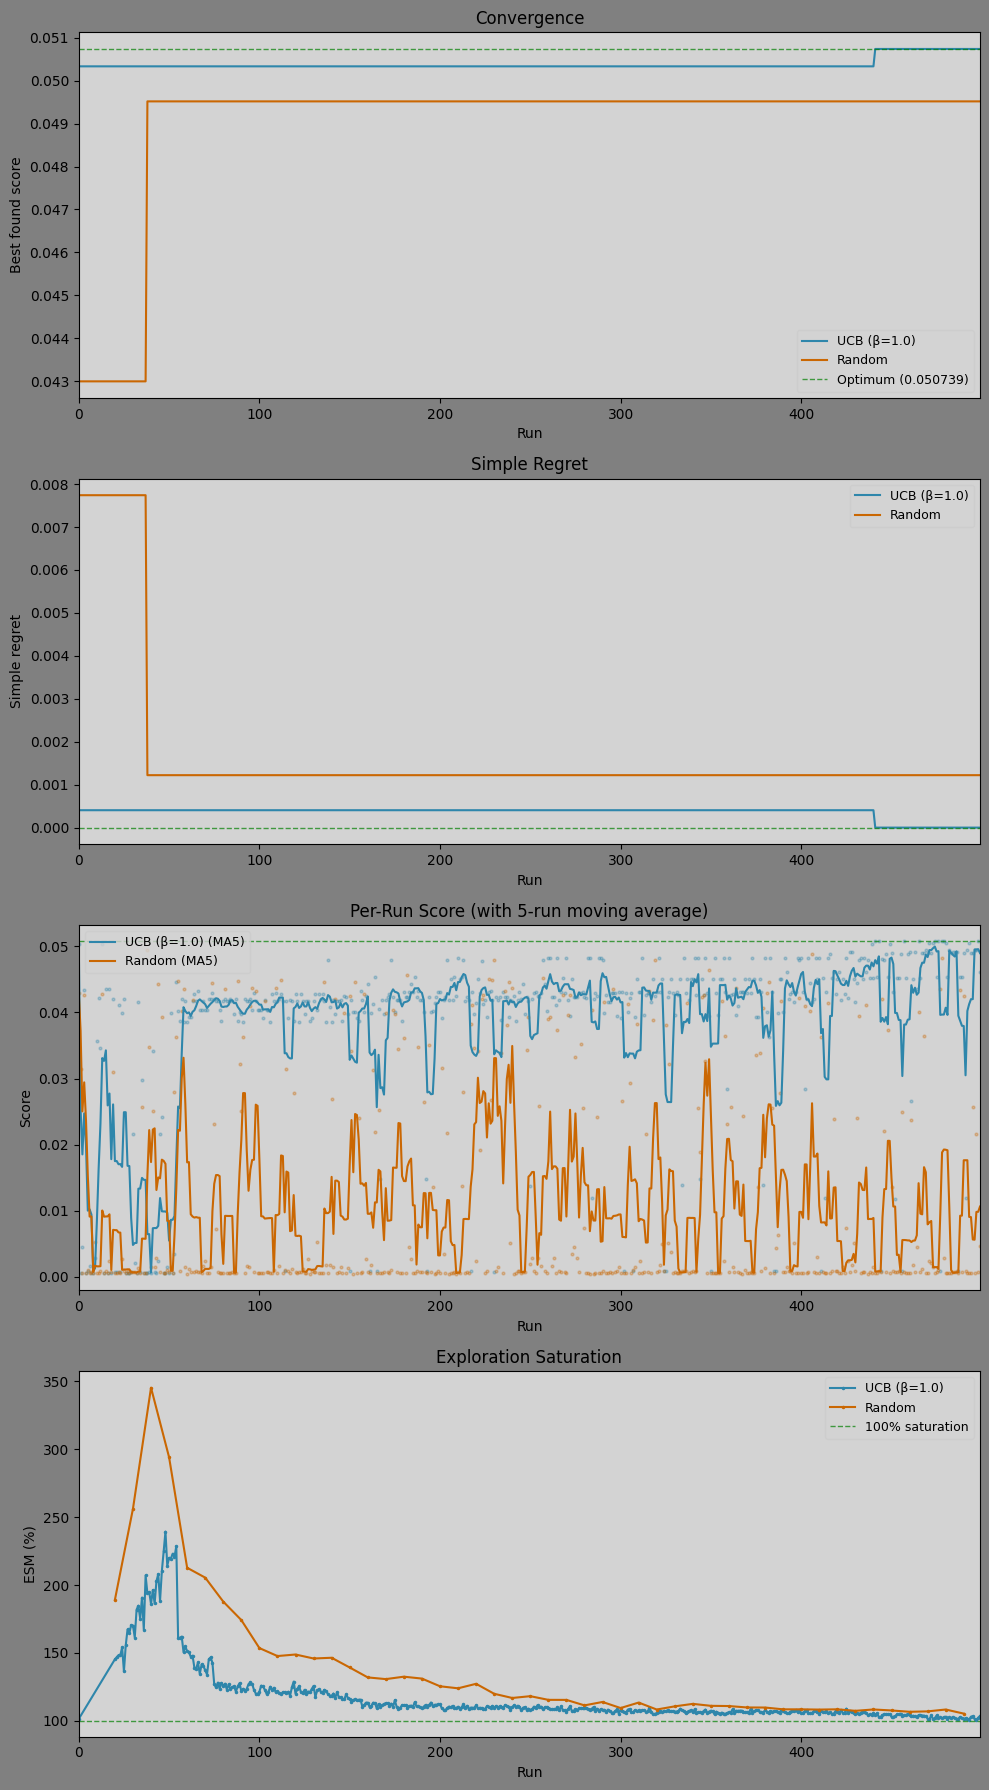

In [15]:
from matplotlib.figure import Figure
from matplotlib.axes import Axes

fig: Figure
axes: list[Axes]
fig, axes = plt.subplots(4, 1, figsize=(10, 18))

strategies = {"ucb": "UCB (β=1.0)", "random": "Random"}
colors = {"ucb": "#2e86ab", "random": "#ca6702"}
global_optimum = best_score

# Plot 1: Best found over runs
ax: Axes = axes[0]
for strategy, label in strategies.items():
    trajectory = all_trajectories.filter(pl.col("strategy") == strategy).sort("run")
    ax.plot(trajectory["run"], trajectory["best_found"], label=label, color=colors[strategy], linewidth=1.5)
ax.axhline(global_optimum, color="green", linestyle="--", linewidth=1, alpha=0.7, label=f"Optimum ({global_optimum:.6f})")
ax.set_xlabel("Run")
ax.set_ylabel("Best found score")
ax.set_title("Convergence")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs - 1)

# Plot 2: Simple regret over runs
ax = axes[1]
for strategy, label in strategies.items():
    trajectory = all_trajectories.filter(pl.col("strategy") == strategy).sort("run")
    ax.plot(trajectory["run"], trajectory["simple_regret"], label=label, color=colors[strategy], linewidth=1.5)
ax.axhline(0, color="green", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Run")
ax.set_ylabel("Simple regret")
ax.set_title("Simple Regret")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs - 1)

# Plot 3: Per-run score
ax = axes[2]
window = 5
for strategy, label in strategies.items():
    trajectory = all_trajectories.filter(pl.col("strategy") == strategy).sort("run")
    ax.scatter(trajectory["run"], trajectory["score"], s=4, alpha=0.3, color=colors[strategy])
    rolling_mean = trajectory.select(
        pl.col("score").shift(0).rolling_mean(window_size=window, min_samples=1)
    ).to_series().to_numpy()
    ax.plot(trajectory["run"], rolling_mean, label=f"{label} (MA{window})", color=colors[strategy], linewidth=1.5)
ax.axhline(global_optimum, color="green", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Run")
ax.set_ylabel("Score")
ax.set_title(f"Per-Run Score (with {window}-run moving average)")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs - 1)

# Plot 4: ESM over runs
ax = axes[3]
for strategy, label in strategies.items():
    trajectory = all_trajectories.filter(pl.col("strategy") == strategy).sort("run")
    esm_data = trajectory.filter(pl.col("esm").is_not_null())
    if len(esm_data) > 0:
        ax.plot(esm_data["run"], esm_data["esm"], label=label, color=colors[strategy], linewidth=1.5, marker=".", markersize=3)
ax.axhline(100, color="green", linestyle="--", linewidth=1, alpha=0.7, label="100% saturation")
ax.set_xlabel("Run")
ax.set_ylabel("ESM (%)")
ax.set_title("Exploration Saturation")
ax.legend(fontsize=9)
ax.set_xlim(0, n_runs - 1)

plt.tight_layout()
plt.show()